**Clustering**

The goal of this notebook is to divide the customers into k clusters based of RFM. It covers a strategy for choosing optimal k and then uses Kmeans as clustering algorithm.

Optimal k turned to be k=4

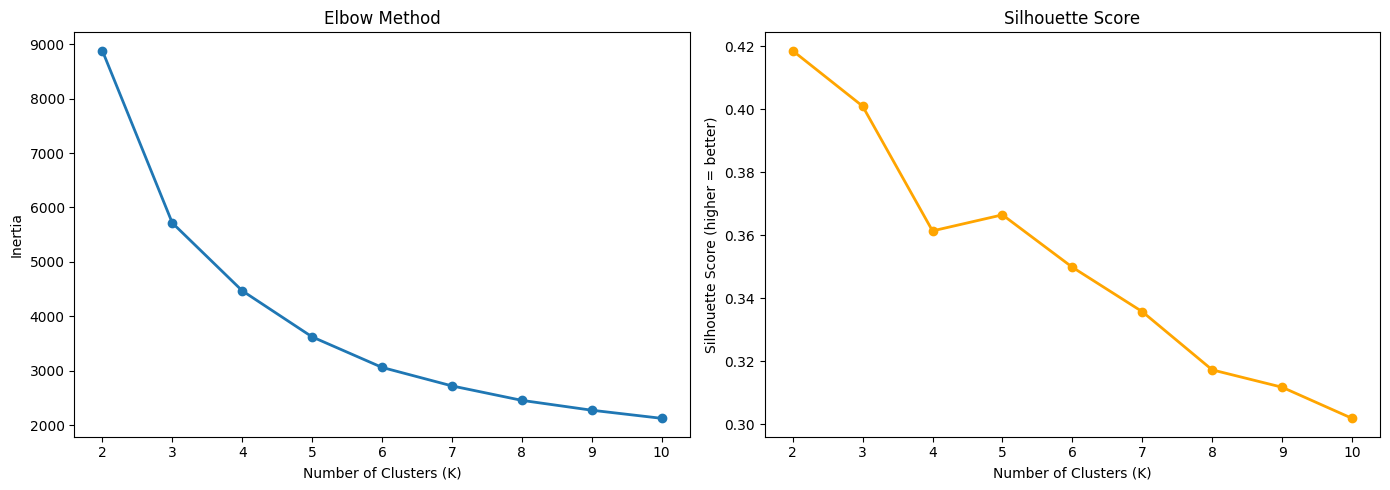

Silhouette scores:
  K=2: 0.4186
  K=3: 0.4010
  K=4: 0.3614
  K=5: 0.3665
  K=6: 0.3499
  K=7: 0.3357
  K=8: 0.3173
  K=9: 0.3117
  K=10: 0.3019


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

rfm = pd.read_csv('data_processed/rfm.csv')

rfm_scaled = rfm[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].values

# Test K from 2 to 10
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

# Plot elbow + silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig('plots/cluster_selection.png', dpi=150)
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouette_scores):
    print(f"  K={k}: {s:.4f}")

In [2]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check how many customers landed in each cluster
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    1638
1    1384
2    1891
3     965
Name: count, dtype: int64


In [3]:
# Look at average RFM values per cluster (use originals, not scaled)
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('Customer ID', 'count')
).round(1)

print(cluster_summary)

         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0               493.5             1.7          538.4            1638
1               106.2             1.7          425.8            1384
2                98.8             5.5         1910.0            1891
3                42.7            22.2        13119.7             965


In [4]:

cluster_labels = {
    3: 'Champions',
    2: 'Loyal',
    1: 'Hibernating',
    0: 'Dormant'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

Segment
Loyal          1891
Dormant        1638
Hibernating    1384
Champions       965
Name: count, dtype: int64


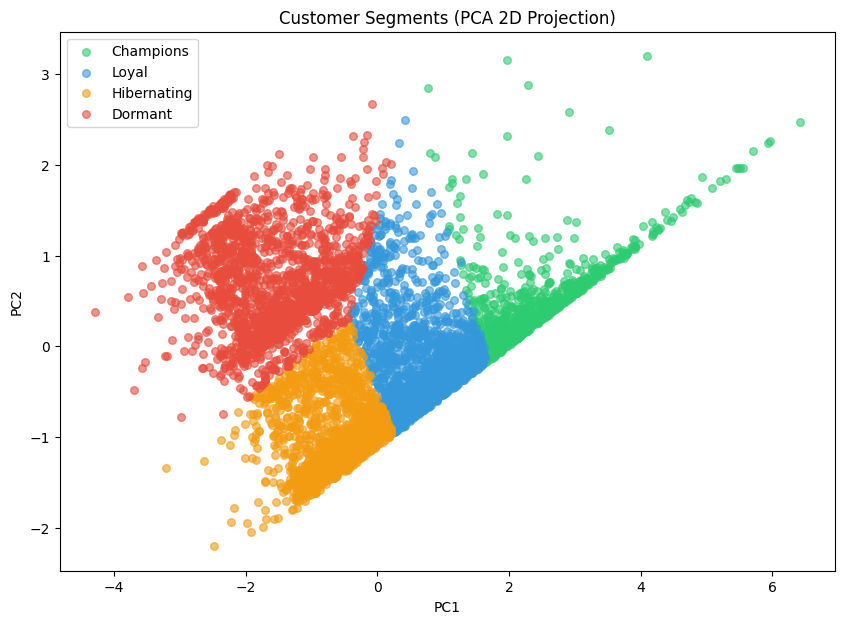

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 7))
colors = {'Champions': '#2ecc71', 'Loyal': '#3498db', 
          'Hibernating': '#f39c12', 'Dormant': '#e74c3c'}

for segment, color in colors.items():
    mask = rfm['Segment'] == segment
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=color, label=segment, alpha=0.6, s=30)

plt.title('Customer Segments (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.savefig('plots/cluster_pca.png', dpi=150)
plt.show()

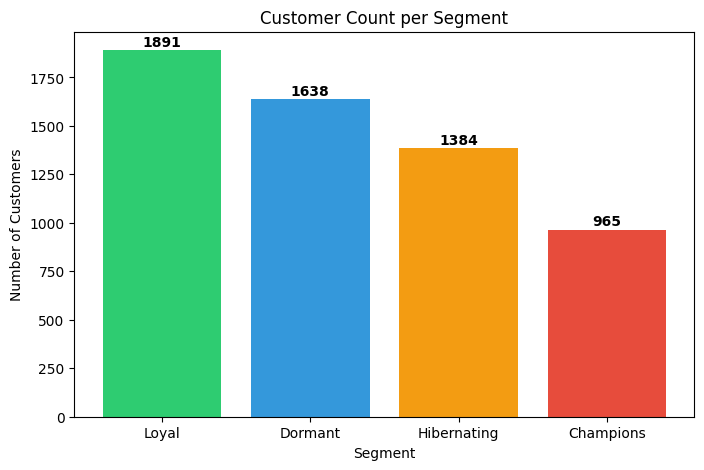

In [6]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, 
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
plt.title('Customer Count per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             str(val), ha='center', fontweight='bold')
plt.savefig('plots/segment_counts.png', dpi=150)
plt.show()

In [7]:
rfm.to_csv('data_processed/rfm_clustered.csv', index=False)